Bước 1: Hiểu bài toán (Problem Understanding)

Bài toán thuộc về sinh văn bản tự động(Natural Language Generation), vận hành dựa trên kiến trúc cốt lõi là Sequence-to-Sequence

Các features hay còn gọi là input chính là nội dung bức thư người khác gửi đến (EmailSend) và toàn bộ ngữ cảnh của cuộc hội thoại trước đó (Context)

Target hay còn gọi là output chính là nội dung bức thư phản hồi tự động (EmailReply).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Bước 2: Hiểu dữ liệu (Data Understanding)

Có giá trị thiếu (missing values) không?

Có outlier (nhiễu) không?

Dữ liệu có không nhất quán (inconsistent) không?

Có bị mất cân bằng (imbalanced) không?

Có lệch phân phối (skewness) không?

In [2]:
# Bước 2: Hiểu dữ liệu (Data Understanding)

import pandas as pd
from IPython.display import display

# đọc dữ liệu
data = pd.read_csv('/home/vophilong/Documents/Deep_learning/Dataset/dataset.csv')

# setting hiển thị đẹp hơn
pd.set_option('display.max_colwidth', 200)  # tránh text quá dài bị cắt
pd.set_option('display.width', 1000) # tăng độ rộng hiển thị

print("5 dòng đầu ")
display(data.head())

print("\nThông tin dữ liệu ")
data.info()

print("\nThống kê mô tả ")
display(data.describe())

print("\nThống kê cho text (quan trọng với NLP) ")
display(data.describe(include='object'))


print("\nXem mẫu dữ liệu dạng dễ đọc ")
for i, row in data.head(3).iterrows():
    print(f"\n--- Sample {i} ---")
    display("EmailSend:\n", row.get('EmailSend', 'N/A'))
    display("EmailReply:\n", row.get('EmailReply', 'N/A'))
    display("SubjectSend:", row.get('SubjectSend', 'N/A'))
    display("SubjectReply:", row.get('SubjectReply', 'N/A'))
    print("-" * 60)


5 dòng đầu 


,EmailSend,EmailReply,SubjectSend,SubjectReply,From,To,DateSend,DateReply,Context
0,"Nikki, Thanks for the note and I hope your doing well. You are right, sometimes introductions sound more like the presentation of a resume than a letter...but I think you pulled it off. I was able...","Hello hello! I was so worried that I had said something in my last E-mail to make you say ""Whoah!!! What was Brendan thinking?"" So when Brendan came in as my patient for a follow-up, I told him ""N...",Portland,Re: Portland,bill.williams@enron.com,-nikole@excite.com,6/18/2001 22:44,6/19/2001 15:49,NaN
1,Jim Lokay Sales Representative British Parts International 800-231-6563 ext. 548 mail,HI,Call when you receive this (no rush),RE: Call when you receive this (no rush),548@britishparts.com,michelle.lokay@enron.com,3/19/2002 8:30,3/19/2002 8:34,NaN
2,Congratulations! Have a good sleep.,"Just woke up...thnx for your note. I believe that UBS was the best fit and the best bid ,excluding the retention. I hope everyone is psyched, you and john worked very hard on this and it was a ple...",Thanks and,Re: Thanks and,louise.kitchen@enron.com,8774754543@skytel.com,1/15/2002 12:30,1/15/2002 16:29,NaN
3,Test,Call back : Geir.Solberg@enron.com|Test|Test,Test,Re: Test,geir.solberg@enron.com,8776519147@skytel.com,1/19/2002 10:55,1/19/2002 10:56,NaN
4,We are dropping a lot of marketers. It would be nice to keep 1 or 2.,As shankman would say 'working ya',Marketers,RE: Marketers,8777865122@skytel.com,louise.kitchen@enron.com,1/21/2002 15:30,1/21/2002 15:44,NaN



Thông tin dữ liệu 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15377 entries, 0 to 15376
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   EmailSend     15377 non-null  object
 1   EmailReply    15377 non-null  object
 2   SubjectSend   14876 non-null  object
 3   SubjectReply  15260 non-null  object
 4   From          15374 non-null  object
 5   To            15119 non-null  object
 6   DateSend      15113 non-null  object
 7   DateReply     15251 non-null  object
 8   Context       5012 non-null   object
dtypes: object(9)
memory usage: 1.1+ MB

Thống kê mô tả 


,EmailSend,EmailReply,SubjectSend,SubjectReply,From,To,DateSend,DateReply,Context
count,15377,15377,14876,15260,15374,15119,15113,15251,5012
unique,15262,14858,9740,7991,3939,3955,14310,14337,5012
top,yep,Thanks.,RE:,RE:,tana.jones@enron.com,jeff.dasovich@enron.com,11/19/2001 12:30,10/29/2001 14:39,Our contact for this is Janice Felton. Her number is 713-267-4210. Please call her on Monday and let her know that ENA wishes to terminate contract 37393 effective 5/31/2002. Ask her what she need...
freq,10,35,1666,1726,449,525,5,4,1



Thống kê cho text (quan trọng với NLP) 


...

'SubjectSend:'

'Thanks and'

'SubjectReply:'

'Re: Thanks and'

------------------------------------------------------------


In [3]:
#Kiểm tra giá trị thiểu 
print("Giá trị thiểu ")
missing_data = data.isnull().sum()
missing_percent = (data.isnull().sum() / len(data)) * 100

# Tạo bảng thống kê các cột bị thiếu dữ liệu
missing_data_table = pd.DataFrame({
    'Cột': missing_data.index,
    'Số lượng giá trị thiếu': missing_data.values,
    'Phần trăm giá trị thiếu (%)': missing_percent.values
})

#In ấn bảng thống kê giá trị thiếu
display(missing_data_table)

Giá trị thiểu 


,Cột,Số lượng giá trị thiếu,Phần trăm giá trị thiếu (%)
0,EmailSend,0,0.000000
1,EmailReply,0,0.000000
2,SubjectSend,501,3.258113
3,SubjectReply,117,0.760877
4,From,3,0.019510
5,To,258,1.677831
6,DateSend,264,1.716850
7,DateReply,126,0.819406
8,Context,10365,67.405866


In [5]:
# Tạo các cột đo lường độ dài văn bản (số lượng ký tự)
# Xử lý các giá trị NaN bằng cách chuyển thành chuỗi rỗng trước khi đếm
data['Send_Len'] = data['EmailSend'].astype(str).apply(len)# chuyển đổi sang string để tránh lỗi khi có NaN
data['Reply_Len'] = data['EmailReply'].astype(str).apply(len)
data['Context_Len'] = data['Context'].fillna("").apply(len)# điền NaN bằng chuỗi rỗng trước khi đếm

# 2. KIỂM TRA DỮ LIỆU KHÔNG NHẤT QUÁN (INCONSISTENT)
print("KIỂM TRA TÍNH NHẤT QUÁN")
# Kiểm tra số dòng trùng lặp hoàn toàn
duplicates = data.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {duplicates}")

# Kiểm tra lỗi logic: Người gửi và người trả lời có nội dung giống hệt nhau không?
same_content = (data['EmailSend'] == data['EmailReply']).sum()
print(f"Số dòng có Email gửi và trả lời giống hệt nhau: {same_content}")

KIỂM TRA TÍNH NHẤT QUÁN
Số dòng trùng lặp hoàn toàn: 0
Số dòng có Email gửi và trả lời giống hệt nhau: 0


THỐNG KÊ ĐỘ DÀI VĂN BẢN (TÌM OUTLIERS)


,Send_Len,Reply_Len
count,15377.000000,15377.000000
mean,284.036418,200.364115
std,419.842916,298.103676
min,2.000000,1.000000
1%,6.000000,4.000000
5%,18.000000,10.000000
50%,164.000000,106.000000
95%,929.000000,688.000000
99%,1879.480000,1428.200000
max,12503.000000,5721.000000



HỆ SỐ LỆCH PHÂN PHỐI (SKEWNESS)
Send_Len     7.352937
Reply_Len    5.255600
dtype: float64


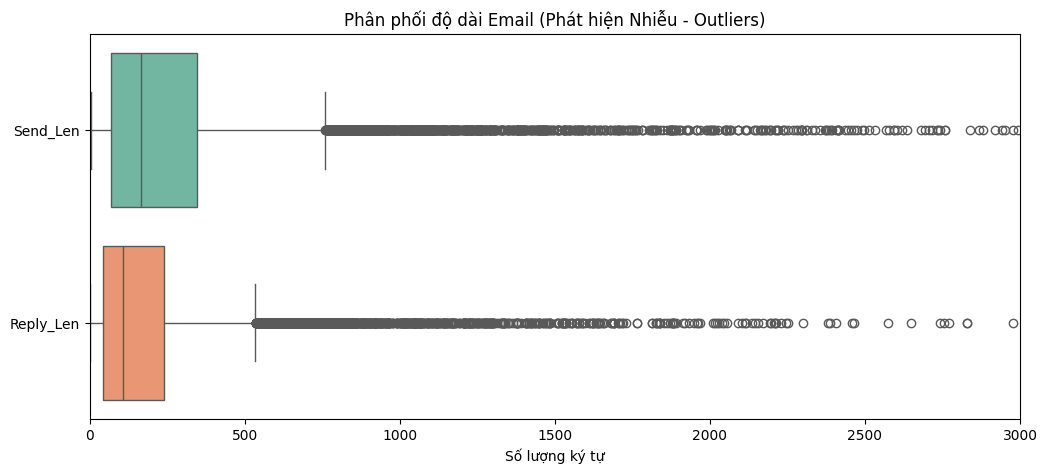

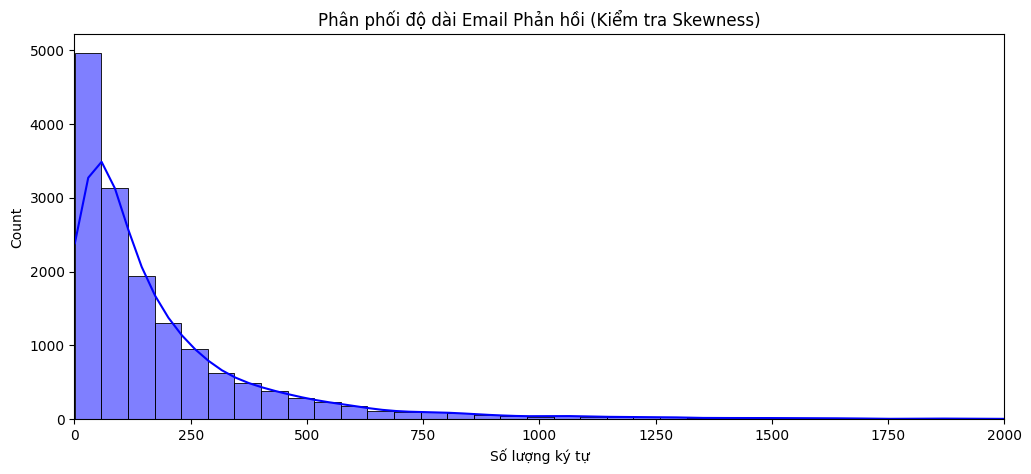

In [ ]:
#KIỂM TRA OUTLIERS BẰNG THỐNG KÊ MÔ TẢ
print("THỐNG KÊ ĐỘ DÀI VĂN BẢN (TÌM OUTLIERS)")
# Sử dụng percentiles để xem xét các mốc 1%, 5%, 95%, 99% nhằm phát hiện ngoại lai
display(data[['Send_Len', 'Reply_Len']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

# KIỂM TRA LỆCH PHÂN PHỐI (SKEWNESS)
print("\nHỆ SỐ LỆCH PHÂN PHỐI (SKEWNESS)")
# Hệ số > 1 hoặc < -1 thể hiện độ lệch rất lớn
print(data[['Send_Len', 'Reply_Len']].skew())

# TRỰC QUAN HÓA BẰNG BIỂU ĐỒ (VISUALIZATION)
# Biểu đồ Boxplot giúp nhìn rõ các điểm Outliers (các chấm đen nằm ngoài râu)
plt.figure(figsize=(12, 5))
sns.boxplot(data=data[['Send_Len', 'Reply_Len']], orient='h', palette='Set2')
plt.title('Phân phối độ dài Email (Phát hiện Nhiễu - Outliers)')
plt.xlabel('Số lượng ký tự')
plt.xlim(0, 3000) # Giới hạn trục X để dễ nhìn hơn do có outlier quá lớn
plt.show()

# Biểu đồ Histogram để xem độ lệch phân phối (Skewness)
plt.figure(figsize=(12, 5))
sns.histplot(data['Reply_Len'], bins=100, kde=True, color='blue')
plt.title('Phân phối độ dài Email Phản hồi (Kiểm tra Skewness)')
plt.xlabel('Số lượng ký tự')
plt.xlim(0, 2000)
plt.show()
    

In [11]:
# KIỂM TRA MẤT CÂN BẰNG CẤU TRÚC (IMBALANCED)
print("--- 5. KIỂM TRA MẤT CÂN BẰNG DỮ LIỆU NGỮ CẢNH ---")
context_missing = data['Context'].isnull().sum()
context_exist = len(data) - context_missing

print(f"Số lượng email CÓ chứa ngữ cảnh (Context): {context_exist} dòng ({(context_exist/len(data))*100:.2f}%)")
print(f"Số lượng email KHÔNG CÓ ngữ cảnh: {context_missing} dòng ({(context_missing/len(data))*100:.2f}%)")

--- 5. KIỂM TRA MẤT CÂN BẰNG DỮ LIỆU NGỮ CẢNH ---
Số lượng email CÓ chứa ngữ cảnh (Context): 5012 dòng (32.59%)
Số lượng email KHÔNG CÓ ngữ cảnh: 10365 dòng (67.41%)
